# 06 — Hovmöller and Spatiotemporal Analysis
## จากแผนที่ ณ เวลาเดียว สู่การวิเคราะห์ Space × Time

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 850-hPa zonal wind teaching dataset  
**ช่วงเวลา:** 1 September–31 October 2011  
**ความถี่เวลา:** ทุก 6 ชั่วโมง  
**บทก่อนหน้า:** Notebook 05 — Synoptic Weather Maps and Atmospheric Dynamics

Notebook นี้ตอบคำถามหลักว่า:

```text
แผนที่บอกอะไร?
        ↓
time series บอกอะไร?
        ↓
Hovmöller diagram คืออะไร?
        ↓
ทำไม Hovmöller จึงเป็น space × time?
        ↓
จะเฉลี่ย latitude หรือ longitude อย่างไร?
        ↓
diagonal pattern บน Hovmöller หมายความว่าอะไร?
        ↓
จะเชื่อม pattern บน Hovmöller กลับไปยังแผนที่จริงอย่างไร?
```

แนวคิดสำคัญ:

> **Map แสดง spatial pattern ณ เวลาใดเวลาหนึ่ง**

> **Hovmöller แสดงการเปลี่ยนแปลงของ spatial pattern ตามเวลา**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบายความแตกต่างระหว่าง map, time series และ Hovmöller diagram
2. ตรวจ temporal cadence จาก coordinate จริง
3. ยืนยันว่าข้อมูลชุดนี้เป็น 6-hourly ไม่ใช่ hourly
4. อธิบาย zonal wind $u$ ที่ 850 hPa
5. สร้าง Time–Longitude Hovmöller diagram
6. ใช้ latitude-weighted mean ด้วย $\cos\phi$
7. สร้าง Time–Latitude Hovmöller diagram
8. อธิบาย diagonal feature บน Hovmöller อย่างระมัดระวัง
9. เชื่อม Hovmöller กับ selected map snapshots
10. สร้าง regional mean time series
11. อธิบายข้อจำกัดของการใช้ตัวแปร $u$ เพียงตัวเดียว
12. export figures, tables และ metadata

# 1. Map, Time Series และ Hovmöller ต่างกันอย่างไร?

### Map

```text
latitude × longitude
at one time
```

ใช้ตอบว่า:

> pattern อยู่ตรงไหน?

### Time Series

```text
time
at one location or area
```

ใช้ตอบว่า:

> ค่าที่ตำแหน่งหรือพื้นที่หนึ่งเปลี่ยนตามเวลาอย่างไร?

### Hovmöller Diagram

```text
space × time
```

ใช้ตอบว่า:

> spatial feature เปลี่ยนหรือเคลื่อนตามเวลาอย่างไร?

# 2. Time–Longitude Hovmöller

ถ้าเฉลี่ยตัวแปรตาม latitude band:

$$
\overline{u}(\lambda,t)
=
\frac{
\sum_{\phi}
u(\lambda,\phi,t)w(\phi)
}{
\sum_{\phi}
w(\phi)
}
$$

โดยใช้ area weighting:

$$
w(\phi)
=
\cos\phi
$$

ผลลัพธ์เหลือสองมิติ:

```text
time × longitude
```

เราจะใช้ latitude band:

```text
10–20°N
```

# 3. ทำไมต้องใช้ $\cos\phi$ Weighting?

บน regular latitude–longitude grid พื้นที่ของ grid cell ลดลงเมื่อ latitude สูงขึ้น

โดยประมาณ:

$$
A
\propto
\cos\phi
$$

ดังนั้นการเฉลี่ยหลาย latitude ควรพิจารณา latitude weighting เพื่อไม่ให้แต่ละ latitude row มีอิทธิพลเท่ากันโดยไม่คำนึงถึงพื้นที่จริง

สำหรับช่วง 10–20°N ความแตกต่างไม่มากเท่าที่ high latitude แต่การสอน weighting ตั้งแต่ต้นช่วยสร้างนิสัยการวิเคราะห์ที่ถูกต้อง

# 4. Time–Latitude Hovmöller

ถ้าเฉลี่ยตาม longitude band:

$$
\overline{u}(\phi,t)
=
\frac{1}{N_\lambda}
\sum_{\lambda}
u(\lambda,\phi,t)
$$

ผลลัพธ์เหลือ:

```text
time × latitude
```

เราจะใช้ longitude band:

```text
95–110°E
```

ซึ่งครอบคลุมประเทศไทย อินโดจีน และพื้นที่ข้างเคียงบางส่วน

# 5. การอ่าน Diagonal Pattern

ถ้า feature ปรากฏเป็นแนวเฉียงบน Time–Longitude diagram:

```text
time increases downward/upward
longitude increases left to right
```

แนวเฉียงอาจสอดคล้องกับ apparent eastward หรือ westward progression ของ pattern

แต่ต้องระวัง:

> **Diagonal pattern ≠ proof of a propagating atmospheric wave automatically**

เพราะ pattern อาจเกิดจาก:

- advection
- evolving circulation
- changing amplitude
- multiple overlapping systems
- averaging effects

# 6. Zonal Wind $u$ ที่ 850 hPa

ข้อมูลใน Notebook นี้มีเฉพาะ $u$

```text
u > 0
→ eastward flow
→ westerly wind

u < 0
→ westward flow
→ easterly wind
```

ดังนั้น Hovmöller ของ $u$ แสดงการเปลี่ยนแปลงของ **zonal component**

ไม่ใช่:

```text
total wind speed
```

และไม่ใช่:

```text
full wind vector
```

# 7. Temporal Resolution

ชื่อไฟล์เดิมอาจทำให้เข้าใจผิดว่าเป็น hourly data

แต่ coordinate จริงต้องเป็นหลักฐานหลัก

ชุดข้อมูลนี้มีเวลา:

```text
00
06
12
18 UTC
```

ดังนั้น temporal cadence คือ:

$$
\Delta t
=
6\ \mathrm{hours}
$$

หลักสำคัญ:

> **อย่าใช้ชื่อไฟล์เป็นหลักฐานแทนการตรวจ coordinate**

# 8. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 9. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print(
    "Google Drive mounted:",
    DRIVE_ROOT,
)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 10. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 11. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "06"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

SPATIOTEMPORAL_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc"
)

if not SPATIOTEMPORAL_FILE.exists():
    raise FileNotFoundError(
        "SPATIOTEMPORAL teaching dataset not found. "
        "Run Notebook 00 first."
    )

print(
    "SPATIOTEMPORAL file:",
    SPATIOTEMPORAL_FILE,
)

SPATIOTEMPORAL file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc


# 12. เปิด SPATIOTEMPORAL dataset

In [5]:
# CELL 5 — Open spatiotemporal dataset

ds = xr.open_dataset(
    SPATIOTEMPORAL_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 12MB
Dimensions:                    (time: 244, latitude: 50, longitude: 240)
Coordinates:
  * time                       (time) datetime64[ns] 2kB 2011-09-01 ... 2011-...
  * latitude                   (latitude) float32 200B 29.88 29.38 ... 5.375
  * longitude                  (longitude) float32 960B 40.12 40.62 ... 159.6
    source_pressure_level_hPa  float64 8B ...
Data variables:
    u                          (time, latitude, longitude) float32 12MB ...
Attributes: (12/18)
    Conventions:                           CF-1.6
    history:                               2022-04-17 06:20:18 GMT by grib_to...
    course:                                Teaching ERA5 Reanalysis and GIS
    dataset_key:                           SPATIOTEMPORAL
    source_type:                           ERA5 atmospheric reanalysis
    source_file:                           era5_hourly4_sep_oct_2011_globe.nc
    ...                                    ...
    created_UTC:               

# 13. Dataset Audit และ Temporal Cadence

In [6]:
# CELL 6 — Dataset and temporal audit

required_variables = {
    "u",
}

missing_variables = (
    required_variables
    - set(
        ds.data_vars
    )
)

if missing_variables:
    raise KeyError(
        f"Missing required variables: {missing_variables}"
    )

time_index = pd.DatetimeIndex(
    pd.to_datetime(
        ds["time"].values
    )
)

time_diffs_hours = (
    pd.Series(
        time_index
    )
    .diff()
    .dropna()
    .dt.total_seconds()
    / 3600.0
)

median_time_step_hours = float(
    time_diffs_hours.median()
)

DATA_AUDIT = pd.DataFrame(
    [
        {
            "item": "time_start",
            "value": str(
                time_index.min()
            ),
        },
        {
            "item": "time_end",
            "value": str(
                time_index.max()
            ),
        },
        {
            "item": "n_time_steps",
            "value": int(
                ds.sizes["time"]
            ),
        },
        {
            "item": "median_time_step_hours",
            "value": median_time_step_hours,
        },
        {
            "item": "latitude_min",
            "value": float(
                ds["latitude"].min()
            ),
        },
        {
            "item": "latitude_max",
            "value": float(
                ds["latitude"].max()
            ),
        },
        {
            "item": "longitude_min",
            "value": float(
                ds["longitude"].min()
            ),
        },
        {
            "item": "longitude_max",
            "value": float(
                ds["longitude"].max()
            ),
        },
        {
            "item": "u_units",
            "value": ds["u"].attrs.get(
                "units",
                "",
            ),
        },
    ]
)

display(
    DATA_AUDIT
)

if np.isclose(
    median_time_step_hours,
    6.0,
):
    print(
        "Confirmed: temporal cadence = 6 hours."
    )
else:
    print(
        "WARNING: temporal cadence differs from expected 6 hours."
    )

,item,value
0,time_start,2011-09-01 00:00:00
1,time_end,2011-10-31 18:00:00
2,n_time_steps,244
3,median_time_step_hours,6.0
4,latitude_min,5.375
5,latitude_max,29.875
6,longitude_min,40.125
7,longitude_max,159.625
8,u_units,m s**-1


Confirmed: temporal cadence = 6 hours.


# 14. ตรวจ Coordinate Ordering

เหมือน Notebook 02 เราต้องตรวจว่า coordinate เรียงอย่างไร โดยเฉพาะ latitude เพราะมีผลต่อ `slice()`

In [7]:
# CELL 7 — Coordinate ordering audit

latitude_values = np.asarray(
    ds["latitude"].values,
    dtype=float,
)

longitude_values = np.asarray(
    ds["longitude"].values,
    dtype=float,
)

lat_order = (
    "increasing"
    if latitude_values[-1] > latitude_values[0]
    else "decreasing"
)

lon_order = (
    "increasing"
    if longitude_values[-1] > longitude_values[0]
    else "decreasing"
)

lat_step = float(
    np.nanmedian(
        np.abs(
            np.diff(
                latitude_values
            )
        )
    )
)

lon_step = float(
    np.nanmedian(
        np.abs(
            np.diff(
                longitude_values
            )
        )
    )
)

COORDINATE_AUDIT = pd.DataFrame(
    [
        {
            "coordinate": "latitude",
            "ordering": lat_order,
            "step_degree": lat_step,
        },
        {
            "coordinate": "longitude",
            "ordering": lon_order,
            "step_degree": lon_step,
        },
    ]
)

display(
    COORDINATE_AUDIT
)

,coordinate,ordering,step_degree
0,latitude,decreasing,0.5
1,longitude,increasing,0.5


# 15. Spatial Helper Functions

In [8]:
# CELL 8 — Coordinate-aware slice and subset

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def spatial_subset(
    data_array,
    *,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
):
    subset = data_array.sel(
        latitude=coordinate_slice(
            data_array["latitude"],
            lat_min,
            lat_max,
        ),
        longitude=coordinate_slice(
            data_array["longitude"],
            lon_min,
            lon_max,
        ),
    )

    if (
        subset.sizes["latitude"] == 0
        or subset.sizes["longitude"] == 0
    ):
        raise ValueError(
            "Spatial subset is empty."
        )

    return subset

# 16. Analysis Bands และ Domains

In [9]:
# CELL 9 — Analysis domains and averaging bands

MAP_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

TIME_LONGITUDE_BAND = {
    "lat_min": 10.0,
    "lat_max": 20.0,
}

TIME_LATITUDE_BAND = {
    "lon_min": 95.0,
    "lon_max": 110.0,
}

THAILAND_BOX = {
    "lon_min": 97.0,
    "lon_max": 106.0,
    "lat_min": 5.0,
    "lat_max": 21.0,
}

ANALYSIS_SETTINGS = pd.DataFrame(
    [
        {
            "analysis": "Time-Longitude Hovmoller",
            "spatial_average": "Latitude-weighted mean",
            "band": "10–20°N",
        },
        {
            "analysis": "Time-Latitude Hovmoller",
            "spatial_average": "Longitude mean",
            "band": "95–110°E",
        },
        {
            "analysis": "Thailand-area time series",
            "spatial_average": "Latitude-weighted regional mean",
            "band": "97–106°E, 5–21°N",
        },
    ]
)

display(
    ANALYSIS_SETTINGS
)

,analysis,spatial_average,band
0,Time-Longitude Hovmoller,Latitude-weighted mean,10–20°N
1,Time-Latitude Hovmoller,Longitude mean,95–110°E
2,Thailand-area time series,Latitude-weighted regional mean,"97–106°E, 5–21°N"


# 17. Figure 06-1 — Dataset Domain and Averaging Bands

ก่อนสร้าง Hovmöller ต้องรู้ว่า spatial averaging เกิดที่ใด

Figure นี้จะแสดง:

```text
Time–Longitude band
→ 10–20°N

Time–Latitude band
→ 95–110°E

Thailand analysis box
→ 97–106°E, 5–21°N
```

การเลือก band เป็นส่วนหนึ่งของ scientific design เพราะ Hovmöller ที่ได้จะเปลี่ยนเมื่อเปลี่ยน averaging domain

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


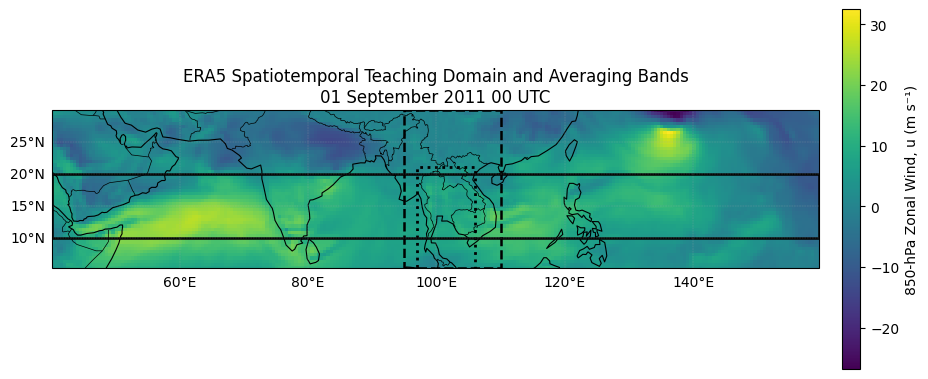

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_01_domain_and_averaging_bands.png


In [10]:
# CELL 10 — Domain and averaging bands map

from matplotlib.patches import Rectangle

u_reference = ds["u"].sel(
    time=time_index[0]
)

fig = plt.figure(
    figsize=(12, 5.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    u_reference["longitude"],
    u_reference["latitude"],
    u_reference,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

# Time–Longitude latitude band
band_lon = Rectangle(
    (
        float(ds["longitude"].min()),
        TIME_LONGITUDE_BAND["lat_min"],
    ),
    float(
        ds["longitude"].max()
        - ds["longitude"].min()
    ),
    (
        TIME_LONGITUDE_BAND["lat_max"]
        - TIME_LONGITUDE_BAND["lat_min"]
    ),
    fill=False,
    linewidth=1.8,
    linestyle="-",
    transform=ccrs.PlateCarree(),
)

# Time–Latitude longitude band
band_lat = Rectangle(
    (
        TIME_LATITUDE_BAND["lon_min"],
        float(ds["latitude"].min()),
    ),
    (
        TIME_LATITUDE_BAND["lon_max"]
        - TIME_LATITUDE_BAND["lon_min"]
    ),
    float(
        ds["latitude"].max()
        - ds["latitude"].min()
    ),
    fill=False,
    linewidth=1.8,
    linestyle="--",
    transform=ccrs.PlateCarree(),
)

# Thailand-area averaging box
thai_box = Rectangle(
    (
        THAILAND_BOX["lon_min"],
        THAILAND_BOX["lat_min"],
    ),
    (
        THAILAND_BOX["lon_max"]
        - THAILAND_BOX["lon_min"]
    ),
    (
        THAILAND_BOX["lat_max"]
        - THAILAND_BOX["lat_min"]
    ),
    fill=False,
    linewidth=2.0,
    linestyle=":",
    transform=ccrs.PlateCarree(),
)

ax.add_patch(
    band_lon
)

ax.add_patch(
    band_lat
)

ax.add_patch(
    thai_box
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
)

ax.set_extent(
    [
        float(ds["longitude"].min()),
        float(ds["longitude"].max()),
        float(ds["latitude"].min()),
        float(ds["latitude"].max()),
    ],
    crs=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.35,
    alpha=0.45,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "850-hPa Zonal Wind, u (m s⁻¹)"
)

ax.set_title(
    "ERA5 Spatiotemporal Teaching Domain and Averaging Bands\n"
    f"{time_index[0]:%d %B %Y %H UTC}"
)

FIG_06_01 = (
    FIGURE_DIR
    / "06_01_domain_and_averaging_bands.png"
)

plt.savefig(
    FIG_06_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_01,
)

# 18. สร้าง Time–Longitude Hovmöller

In [11]:
# CELL 11 — Latitude-weighted mean for Time–Longitude Hovmöller

u_lat_band = ds["u"].sel(
    latitude=coordinate_slice(
        ds["latitude"],
        TIME_LONGITUDE_BAND["lat_min"],
        TIME_LONGITUDE_BAND["lat_max"],
    )
)

latitude_weights = np.cos(
    np.deg2rad(
        u_lat_band["latitude"]
    )
)

hov_time_lon = (
    u_lat_band
    .weighted(
        latitude_weights
    )
    .mean(
        dim="latitude"
    )
)

hov_time_lon.name = (
    "u850_latitude_weighted_mean"
)

hov_time_lon.attrs.update(
    {
        "long_name": (
            "850-hPa zonal wind averaged over 10–20°N"
        ),
        "units": "m s-1",
        "averaging_method": (
            "cos(latitude)-weighted mean"
        ),
    }
)

print(
    hov_time_lon
)

<xarray.DataArray 'u850_latitude_weighted_mean' (time: 244, longitude: 240)> Size: 234kB
array([[ 5.51921   ,  5.396185  ,  5.499857  , ..., -7.6925726 ,
        -7.7539816 , -7.646487  ],
       [ 5.5081096 ,  6.068585  ,  5.7345247 , ..., -5.2772818 ,
        -5.3390255 , -5.318964  ],
       [ 4.4507117 ,  4.7697544 ,  4.6743417 , ..., -5.2875967 ,
        -5.342954  , -5.334166  ],
       ...,
       [ 0.667492  ,  0.01367518, -0.14280419, ..., -9.705496  ,
        -9.752464  , -9.754855  ],
       [-0.63057953,  0.13071379,  0.76417565, ..., -8.849251  ,
        -8.703519  , -8.612475  ],
       [ 0.23271325, -0.5369453 , -0.63169646, ..., -8.806203  ,
        -8.517392  , -8.279526  ]], dtype=float32)
Coordinates:
  * time                       (time) datetime64[ns] 2kB 2011-09-01 ... 2011-...
  * longitude                  (longitude) float32 960B 40.12 40.62 ... 159.6
    source_pressure_level_hPa  float64 8B 850.0
Attributes:
    units:             m s-1
    long_name:        

# 19. Figure 06-2 — Time–Longitude Hovmöller

แกน:

```text
x → longitude
y → time
shading → latitude-weighted mean u850
```

ใช้ zero-centered normalization เพื่อให้ sign ของ $u$ มี reference ที่ชัดเจน

```text
u > 0 → eastward component
u < 0 → westward component
```

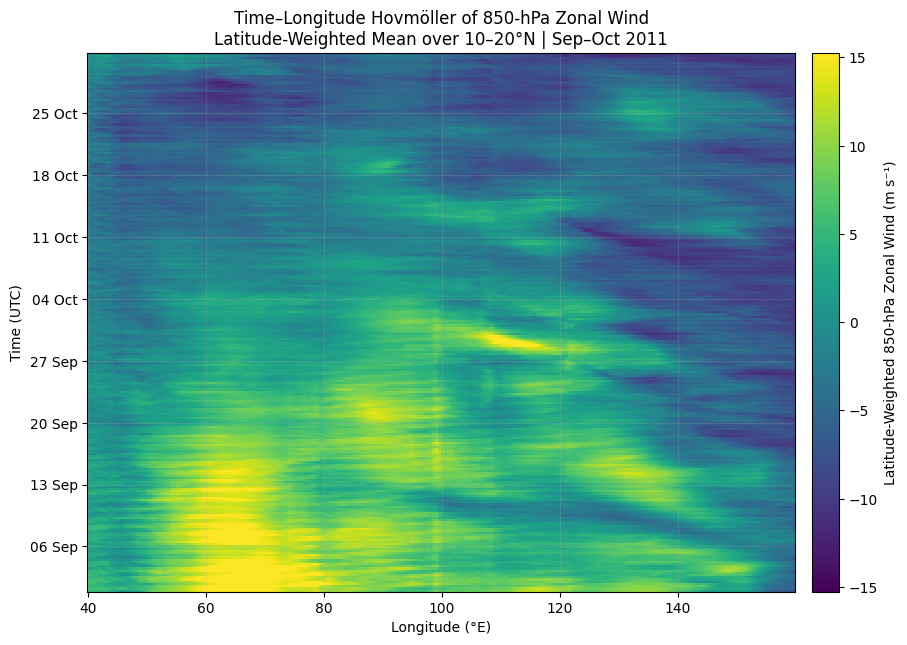

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_02_time_longitude_hovmoller_u850.png


In [12]:
# CELL 12 — Time–Longitude Hovmöller figure

hov_lon_abs = float(
    np.nanpercentile(
        np.abs(
            hov_time_lon.values
        ),
        99,
    )
)

hov_lon_abs = max(
    hov_lon_abs,
    1.0,
)

norm_lon = TwoSlopeNorm(
    vmin=-hov_lon_abs,
    vcenter=0.0,
    vmax=hov_lon_abs,
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

mesh = ax.pcolormesh(
    hov_time_lon["longitude"],
    hov_time_lon["time"],
    hov_time_lon,
    shading="auto",
    norm=norm_lon,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Latitude-Weighted 850-hPa Zonal Wind (m s⁻¹)"
)

ax.set_xlabel(
    "Longitude (°E)"
)

ax.set_ylabel(
    "Time (UTC)"
)

ax.set_title(
    "Time–Longitude Hovmöller of 850-hPa Zonal Wind\n"
    "Latitude-Weighted Mean over 10–20°N | Sep–Oct 2011"
)

ax.yaxis.set_major_locator(
    mdates.WeekdayLocator(
        interval=1
    )
)

ax.yaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b"
    )
)

ax.grid(
    True,
    alpha=0.2,
)

FIG_06_02 = (
    FIGURE_DIR
    / "06_02_time_longitude_hovmoller_u850.png"
)

plt.savefig(
    FIG_06_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_02,
)

# 20. อ่าน Time–Longitude Hovmöller อย่างไร?

เริ่มจากคำถาม:

1. บริเวณ longitude ใดมี $u>0$ หรือ $u<0$ เด่น?
2. pattern คงอยู่หลายวันหรือเปลี่ยนเร็ว?
3. feature มีแนวเกือบตั้งตรงหรือเฉียง?
4. sign เปลี่ยนในช่วงใด?
5. pattern ก่อนและระหว่าง 2–5 October แตกต่างกันอย่างไร?

ถ้า feature เป็นแนวตั้ง อาจสอดคล้องกับ persistence

ถ้า feature เป็นแนวเฉียง อาจสอดคล้องกับ apparent progression แต่ต้องตรวจด้วย maps

# 21. สร้าง Time–Latitude Hovmöller

In [13]:
# CELL 13 — Longitude mean for Time–Latitude Hovmöller

u_lon_band = ds["u"].sel(
    longitude=coordinate_slice(
        ds["longitude"],
        TIME_LATITUDE_BAND["lon_min"],
        TIME_LATITUDE_BAND["lon_max"],
    )
)

hov_time_lat = (
    u_lon_band
    .mean(
        dim="longitude"
    )
)

hov_time_lat.name = (
    "u850_longitude_mean"
)

hov_time_lat.attrs.update(
    {
        "long_name": (
            "850-hPa zonal wind averaged over 95–110°E"
        ),
        "units": "m s-1",
        "averaging_method": (
            "Arithmetic mean across longitude"
        ),
    }
)

print(
    hov_time_lat
)

<xarray.DataArray 'u850_longitude_mean' (time: 244, latitude: 50)> Size: 49kB
array([[-2.0998494e-01, -2.0609418e-01, -1.7903805e-02, ...,
         4.5952907e+00,  3.7964838e+00,  3.0147753e+00],
       [-1.4576641e+00, -1.0864027e+00, -6.9229412e-01, ...,
         4.6562567e+00,  3.7939672e+00,  2.9256537e+00],
       [-1.2742860e+00, -1.2424577e+00, -1.3158119e+00, ...,
         4.7172499e+00,  3.7261426e+00,  2.8883111e+00],
       ...,
       [ 3.0804315e-01,  1.1780509e-01, -3.3684869e-04, ...,
        -1.2442960e+01, -1.1108512e+01, -8.2214880e+00],
       [-7.3525345e-01, -8.7622809e-01, -9.8026955e-01, ...,
        -1.0768172e+01, -9.9232321e+00, -7.8356147e+00],
       [-2.4203260e-01, -6.0617059e-01, -7.5953418e-01, ...,
        -9.0443859e+00, -8.3666334e+00, -6.5230947e+00]], dtype=float32)
Coordinates:
  * time                       (time) datetime64[ns] 2kB 2011-09-01 ... 2011-...
  * latitude                   (latitude) float32 200B 29.88 29.38 ... 5.375
    source_pres

# 22. Figure 06-3 — Time–Latitude Hovmöller

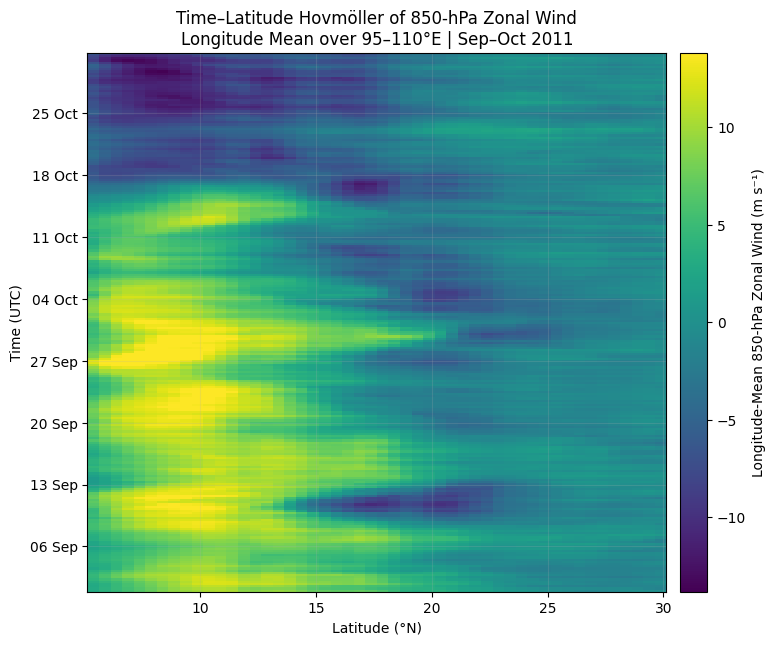

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_03_time_latitude_hovmoller_u850.png


In [14]:
# CELL 14 — Time–Latitude Hovmöller figure

hov_lat_abs = float(
    np.nanpercentile(
        np.abs(
            hov_time_lat.values
        ),
        99,
    )
)

hov_lat_abs = max(
    hov_lat_abs,
    1.0,
)

norm_lat = TwoSlopeNorm(
    vmin=-hov_lat_abs,
    vcenter=0.0,
    vmax=hov_lat_abs,
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

mesh = ax.pcolormesh(
    hov_time_lat["latitude"],
    hov_time_lat["time"],
    hov_time_lat,
    shading="auto",
    norm=norm_lat,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Longitude-Mean 850-hPa Zonal Wind (m s⁻¹)"
)

ax.set_xlabel(
    "Latitude (°N)"
)

ax.set_ylabel(
    "Time (UTC)"
)

ax.set_title(
    "Time–Latitude Hovmöller of 850-hPa Zonal Wind\n"
    "Longitude Mean over 95–110°E | Sep–Oct 2011"
)

ax.yaxis.set_major_locator(
    mdates.WeekdayLocator(
        interval=1
    )
)

ax.yaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b"
    )
)

ax.grid(
    True,
    alpha=0.2,
)

FIG_06_03 = (
    FIGURE_DIR
    / "06_03_time_latitude_hovmoller_u850.png"
)

plt.savefig(
    FIG_06_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_03,
)

# 23. การอ่าน Time–Latitude Hovmöller

Time–Latitude diagram เหมาะกับคำถามเช่น:

```text
pattern ขยายขึ้นเหนือหรือใต้หรือไม่?
sign ของ zonal wind เปลี่ยนตาม latitude อย่างไร?
latitude ใดมี persistence มากที่สุด?
```

แต่การเฉลี่ย 95–110°E ทำให้ longitudinal structure ถูกลดทอน

ดังนั้น:

> **Hovmöller เป็นการย่อข้อมูลเพื่อเน้นคำถามหนึ่ง และย่อมสูญเสีย information บางส่วน**

# 24. เลือก Map Snapshots เพื่อเชื่อม Hovmöller กลับสู่แผนที่

In [15]:
# CELL 15 — Selected snapshot times

SELECTED_SNAPSHOT_TIMES = pd.DatetimeIndex(
    pd.to_datetime(
        [
            "2011-09-20 00:00:00",
            "2011-10-01 00:00:00",
            "2011-10-05 00:00:00",
            "2011-10-15 00:00:00",
        ]
    )
)

missing_snapshot_times = [
    time_value
    for time_value in SELECTED_SNAPSHOT_TIMES
    if time_value not in time_index
]

if missing_snapshot_times:
    raise ValueError(
        f"Snapshot times unavailable: {missing_snapshot_times}"
    )

SNAPSHOT_TABLE = pd.DataFrame(
    {
        "snapshot_time_UTC": (
            SELECTED_SNAPSHOT_TIMES
        )
    }
)

display(
    SNAPSHOT_TABLE
)

,snapshot_time_UTC
0,2011-09-20
1,2011-10-01
2,2011-10-05
3,2011-10-15


# 25. Figure 06-4 — Selected 850-hPa Zonal-Wind Maps

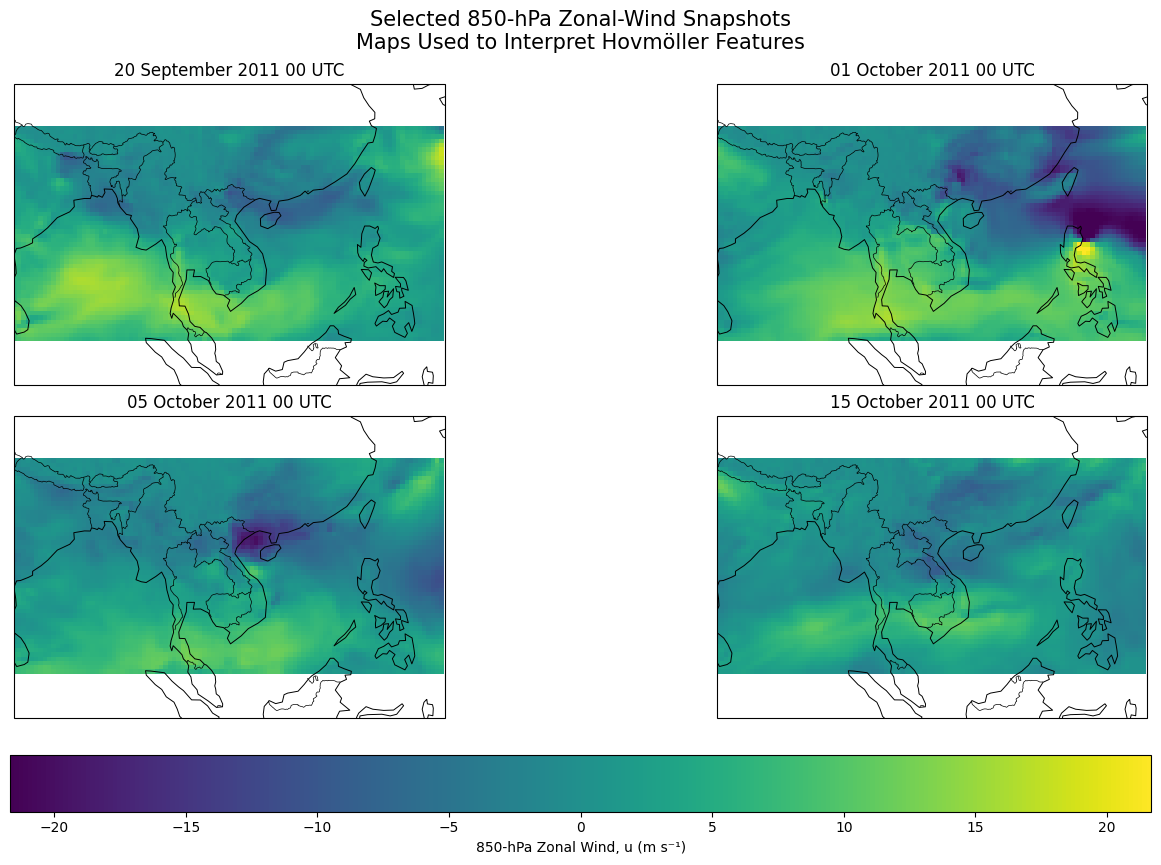

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_04_selected_u850_map_snapshots.png


In [16]:
# CELL 16 — Selected zonal-wind map snapshots

snapshot_fields = []

for time_value in SELECTED_SNAPSHOT_TIMES:
    field = spatial_subset(
        ds["u"].sel(
            time=time_value
        ),
        lon_min=MAP_DOMAIN["lon_min"],
        lon_max=MAP_DOMAIN["lon_max"],
        lat_min=MAP_DOMAIN["lat_min"],
        lat_max=MAP_DOMAIN["lat_max"],
    )

    snapshot_fields.append(
        {
            "time": time_value,
            "field": field,
        }
    )

snapshot_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                item["field"].values
            ),
            99,
        )
        for item in snapshot_fields
    )
)

snapshot_abs = max(
    snapshot_abs,
    1.0,
)

snapshot_norm = TwoSlopeNorm(
    vmin=-snapshot_abs,
    vcenter=0.0,
    vmax=snapshot_abs,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8.5),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, item in zip(
    axes,
    snapshot_fields,
):
    field = item["field"]

    mesh = ax.pcolormesh(
        field["longitude"],
        field["latitude"],
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        norm=snapshot_norm,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            MAP_DOMAIN["lon_min"],
            MAP_DOMAIN["lon_max"],
            MAP_DOMAIN["lat_min"],
            MAP_DOMAIN["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.set_title(
        pd.Timestamp(
            item["time"]
        ).strftime(
            "%d %B %Y %H UTC"
        )
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.05,
    shrink=0.82,
)

cbar.set_label(
    "850-hPa Zonal Wind, u (m s⁻¹)"
)

fig.suptitle(
    "Selected 850-hPa Zonal-Wind Snapshots\n"
    "Maps Used to Interpret Hovmöller Features",
    fontsize=15,
)

FIG_06_04 = (
    FIGURE_DIR
    / "06_04_selected_u850_map_snapshots.png"
)

plt.savefig(
    FIG_06_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_04,
)

# 26. Thailand-Area Mean Time Series

Hovmöller ช่วยดู space × time แต่บางครั้งเราต้องการย่อ spatial dimension ทั้งหมดให้เหลือ time series หนึ่งเส้น

สำหรับพื้นที่ประเทศไทยและข้างเคียง:

```text
97–106°E
5–21°N
```

เราจะใช้ latitude weighting ด้วย $\cos\phi$ แล้วเฉลี่ยทั้ง latitude และ longitude

In [17]:
# CELL 17 — Thailand-area weighted mean time series

u_thailand = spatial_subset(
    ds["u"],
    lon_min=THAILAND_BOX["lon_min"],
    lon_max=THAILAND_BOX["lon_max"],
    lat_min=THAILAND_BOX["lat_min"],
    lat_max=THAILAND_BOX["lat_max"],
)

thai_lat_weights = np.cos(
    np.deg2rad(
        u_thailand["latitude"]
    )
)

u_thailand_mean = (
    u_thailand
    .weighted(
        thai_lat_weights
    )
    .mean(
        dim=(
            "latitude",
            "longitude",
        )
    )
)

u_thailand_mean.name = (
    "u850_thailand_area_mean"
)

u_thailand_mean.attrs.update(
    {
        "long_name": (
            "Area-mean 850-hPa zonal wind over Thailand box"
        ),
        "units": "m s-1",
        "averaging_method": (
            "cos(latitude)-weighted regional mean"
        ),
    }
)

print(
    u_thailand_mean
)

<xarray.DataArray 'u850_thailand_area_mean' (time: 244)> Size: 976B
array([ 6.643137  ,  6.122692  ,  6.645935  ,  8.136562  ,  7.6167865 ,
        7.9378767 ,  7.877618  ,  8.22605   ,  6.9807634 ,  5.2009053 ,
        5.2888856 ,  6.175598  ,  5.266173  ,  4.993358  ,  4.892665  ,
        5.1657505 ,  4.6188207 ,  5.0813966 ,  5.4468694 ,  5.573681  ,
        5.4825606 ,  5.8599763 ,  6.837511  ,  7.7289805 ,  7.8050175 ,
        7.025747  ,  7.613367  ,  8.390327  ,  8.27226   ,  7.98169   ,
        7.7112145 ,  7.690872  ,  6.263152  ,  5.025686  ,  4.7678065 ,
        5.245163  ,  3.2174845 ,  3.5997658 ,  3.1329224 ,  2.4977508 ,
        2.4986067 ,  3.0035596 ,  3.6452613 ,  5.11269   ,  5.8579373 ,
        5.8254666 ,  5.831853  ,  6.336123  ,  6.275725  ,  6.1320343 ,
        6.7879214 ,  7.412697  ,  7.35496   ,  7.5751925 ,  8.156978  ,
        8.979469  ,  8.163089  ,  7.981571  ,  7.7350926 ,  8.376303  ,
        8.534838  ,  7.667538  ,  7.5453157 ,  8.45206   ,  7.798023

# 27. Rolling Mean เพื่อดู Background Variation

ข้อมูลเป็น 6-hourly:

```text
4 time steps per day
```

ดังนั้น 7-day rolling mean ใช้ประมาณ:

$$
7\times4
=
28\ \mathrm{time\ steps}
$$

rolling mean ช่วยลด short-term variability เพื่อเห็น background evolution

แต่:

> **rolling mean เป็น filtered representation ไม่ใช่ข้อมูลต้นฉบับ**

In [18]:
# CELL 18 — 7-day rolling mean

ROLLING_DAYS = 7

steps_per_day = int(
    round(
        24.0
        / median_time_step_hours
    )
)

rolling_window_steps = (
    ROLLING_DAYS
    * steps_per_day
)

u_thailand_7day = (
    u_thailand_mean
    .rolling(
        time=rolling_window_steps,
        center=True,
        min_periods=(
            rolling_window_steps
            // 2
        ),
    )
    .mean()
)

print(
    "Steps per day:",
    steps_per_day,
)

print(
    "7-day rolling window:",
    rolling_window_steps,
    "time steps",
)

Steps per day: 4
7-day rolling window: 28 time steps


# 28. Figure 06-5 — Thailand-Area Mean Zonal Wind through Time

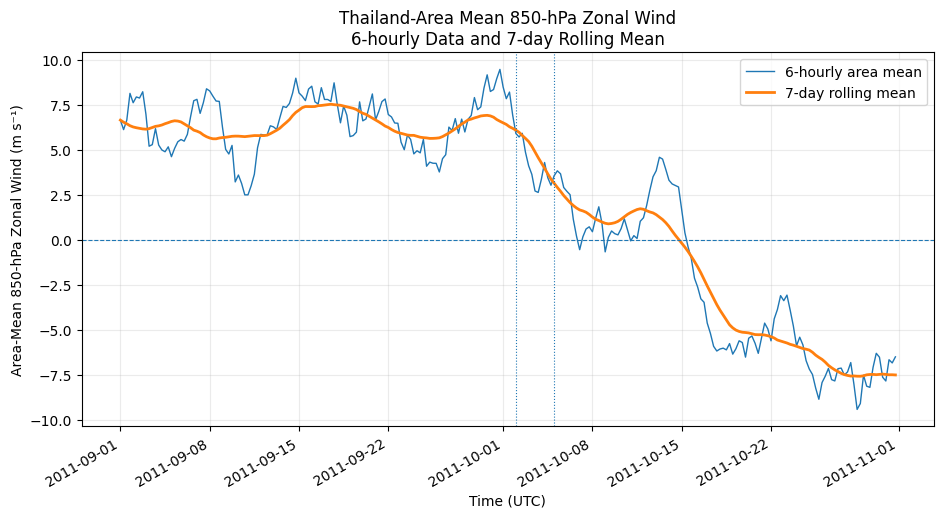

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_05_thailand_area_mean_u850_time_series.png


In [19]:
# CELL 19 — Regional mean time series

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

ax.plot(
    u_thailand_mean["time"],
    u_thailand_mean,
    linewidth=1.0,
    label="6-hourly area mean",
)

ax.plot(
    u_thailand_7day["time"],
    u_thailand_7day,
    linewidth=2.0,
    label="7-day rolling mean",
)

ax.axhline(
    0.0,
    linewidth=0.8,
    linestyle="--",
)

for marker_time in [
    pd.Timestamp(
        "2011-10-02"
    ),
    pd.Timestamp(
        "2011-10-05"
    ),
]:
    ax.axvline(
        marker_time,
        linewidth=0.8,
        linestyle=":",
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Area-Mean 850-hPa Zonal Wind (m s⁻¹)"
)

ax.set_title(
    "Thailand-Area Mean 850-hPa Zonal Wind\n"
    "6-hourly Data and 7-day Rolling Mean"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

fig.autofmt_xdate()

FIG_06_05 = (
    FIGURE_DIR
    / "06_05_thailand_area_mean_u850_time_series.png"
)

plt.savefig(
    FIG_06_05,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_05,
)

# 29. Event-Window Zoom

Full September–October Hovmöller เหมาะกับ background context

แต่บางครั้ง event interpretation ต้อง zoom ช่วงเวลาสั้นลง

เราจะใช้:

```text
25 September–10 October 2011
```

เพื่อดูรายละเอียดรอบ teaching case window 2–5 October

หลักสำคัญ:

> **การ zoom time window ช่วยอ่านรายละเอียด แต่ไม่ควรแทน full-period context**

In [20]:
# CELL 20 — Event-window subset

EVENT_WINDOW_START = pd.Timestamp(
    "2011-09-25 00:00:00"
)

EVENT_WINDOW_END = pd.Timestamp(
    "2011-10-10 18:00:00"
)

hov_event = hov_time_lon.sel(
    time=slice(
        EVENT_WINDOW_START,
        EVENT_WINDOW_END,
    )
)

print(
    hov_event
)

<xarray.DataArray 'u850_latitude_weighted_mean' (time: 64, longitude: 240)> Size: 61kB
array([[  1.3227999 ,   0.64148635,   0.8602617 , ...,  -9.659002  ,
         -9.612997  ,  -9.606187  ],
       [  0.48295885,   0.80757827,   1.0955224 , ...,  -9.941219  ,
         -9.921734  ,  -9.8883    ],
       [  0.4157242 ,   1.0046252 ,   1.3408254 , ..., -10.861717  ,
        -10.847588  , -10.924976  ],
       ...,
       [ -3.1610606 ,  -3.0823653 ,  -3.0135133 , ..., -10.221518  ,
        -10.668359  , -10.881532  ],
       [ -3.563606  ,  -3.10629   ,  -2.6240962 , ...,  -9.291282  ,
         -9.273688  ,  -9.328567  ],
       [ -1.8670775 ,  -2.0331433 ,  -2.2711573 , ...,  -8.482243  ,
         -8.509253  ,  -8.439405  ]], dtype=float32)
Coordinates:
  * time                       (time) datetime64[ns] 512B 2011-09-25 ... 2011...
  * longitude                  (longitude) float32 960B 40.12 40.62 ... 159.6
    source_pressure_level_hPa  float64 8B 850.0
Attributes:
    units:       

# 30. Figure 06-6 — Event-Window Time–Longitude Hovmöller

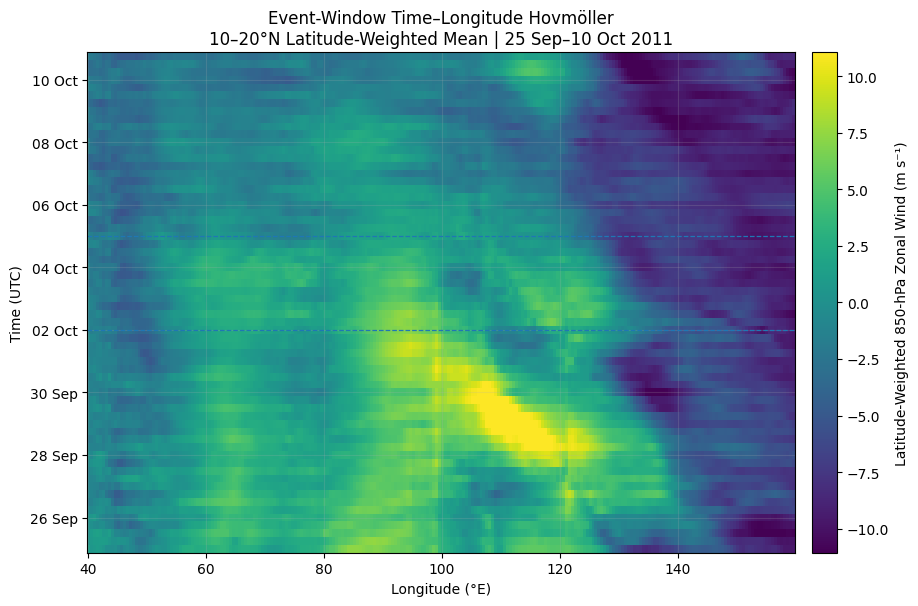

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/06/06_06_event_window_time_longitude_hovmoller.png


In [21]:
# CELL 21 — Event-window Hovmöller

event_abs = float(
    np.nanpercentile(
        np.abs(
            hov_event.values
        ),
        99,
    )
)

event_abs = max(
    event_abs,
    1.0,
)

event_norm = TwoSlopeNorm(
    vmin=-event_abs,
    vcenter=0.0,
    vmax=event_abs,
)

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

mesh = ax.pcolormesh(
    hov_event["longitude"],
    hov_event["time"],
    hov_event,
    shading="auto",
    norm=event_norm,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Latitude-Weighted 850-hPa Zonal Wind (m s⁻¹)"
)

for marker_time in [
    pd.Timestamp(
        "2011-10-02 00:00:00"
    ),
    pd.Timestamp(
        "2011-10-05 00:00:00"
    ),
]:
    ax.axhline(
        marker_time,
        linewidth=0.9,
        linestyle="--",
    )

ax.set_xlabel(
    "Longitude (°E)"
)

ax.set_ylabel(
    "Time (UTC)"
)

ax.set_title(
    "Event-Window Time–Longitude Hovmöller\n"
    "10–20°N Latitude-Weighted Mean | 25 Sep–10 Oct 2011"
)

ax.yaxis.set_major_locator(
    mdates.DayLocator(
        interval=2
    )
)

ax.yaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b"
    )
)

ax.grid(
    True,
    alpha=0.2,
)

FIG_06_06 = (
    FIGURE_DIR
    / "06_06_event_window_time_longitude_hovmoller.png"
)

plt.savefig(
    FIG_06_06,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_06_06,
)

# 31. Apparent Propagation Speed — แนวคิดสำหรับการทดลอง

ถ้านิสิตเลือก feature เดียวกันบน Time–Longitude Hovmöller ที่สองตำแหน่ง สามารถประมาณ apparent propagation speed ได้

$$
c
\approx
\frac{\Delta x}{\Delta t}
$$

สำหรับ longitude difference ที่ mean latitude $\phi$:

$$
\Delta x
\approx
111.32
\cos\phi
\Delta\lambda
$$

โดย $\Delta x$ มีหน่วย km เมื่อ $\Delta\lambda$ เป็น degree

แต่คำว่า **apparent** สำคัญมาก เพราะ Hovmöller feature อาจไม่ได้เป็นวัตถุหรือ wave packet เดียวกันจริง

# 32. Spatiotemporal Summary Statistics

In [22]:
# CELL 22 — Summary statistics

SPATIOTEMPORAL_STATS = pd.DataFrame(
    [
        {
            "diagnostic": (
                "Time-Longitude u850"
            ),
            "minimum_ms": float(
                hov_time_lon.min()
            ),
            "mean_ms": float(
                hov_time_lon.mean()
            ),
            "maximum_ms": float(
                hov_time_lon.max()
            ),
        },
        {
            "diagnostic": (
                "Time-Latitude u850"
            ),
            "minimum_ms": float(
                hov_time_lat.min()
            ),
            "mean_ms": float(
                hov_time_lat.mean()
            ),
            "maximum_ms": float(
                hov_time_lat.max()
            ),
        },
        {
            "diagnostic": (
                "Thailand-area mean u850"
            ),
            "minimum_ms": float(
                u_thailand_mean.min()
            ),
            "mean_ms": float(
                u_thailand_mean.mean()
            ),
            "maximum_ms": float(
                u_thailand_mean.max()
            ),
        },
    ]
)

display(
    SPATIOTEMPORAL_STATS
)

,diagnostic,minimum_ms,mean_ms,maximum_ms
0,Time-Longitude u850,-12.266847,0.187839,20.261717
1,Time-Latitude u850,-13.732031,0.963980,16.990669
2,Thailand-area mean u850,-9.420980,2.185215,9.467574


# 33. Export Derived Spatiotemporal Products

In [23]:
# CELL 23 — Export derived products

THAILAND_TIME_SERIES_CSV = (
    OUTPUT_DIR
    / "06_thailand_area_mean_u850.csv"
)

SNAPSHOT_TABLE_CSV = (
    OUTPUT_DIR
    / "06_selected_snapshot_times.csv"
)

SPATIOTEMPORAL_STATS_CSV = (
    OUTPUT_DIR
    / "06_spatiotemporal_summary_statistics.csv"
)

HOVMOLLER_NETCDF = (
    OUTPUT_DIR
    / "06_hovmoller_derived_fields.nc"
)

SPATIOTEMPORAL_METADATA_CSV = (
    METADATA_DIR
    / "06_spatiotemporal_analysis_metadata.csv"
)

time_series_df = pd.DataFrame(
    {
        "time_UTC": pd.to_datetime(
            u_thailand_mean["time"].values
        ),
        "u850_area_mean_ms": (
            u_thailand_mean.values
        ),
        "u850_7day_rolling_mean_ms": (
            u_thailand_7day.values
        ),
    }
)

time_series_df.to_csv(
    THAILAND_TIME_SERIES_CSV,
    index=False,
)

SNAPSHOT_TABLE.to_csv(
    SNAPSHOT_TABLE_CSV,
    index=False,
)

SPATIOTEMPORAL_STATS.to_csv(
    SPATIOTEMPORAL_STATS_CSV,
    index=False,
)

derived_ds = xr.Dataset(
    {
        "u850_time_longitude": (
            hov_time_lon
        ),
        "u850_time_latitude": (
            hov_time_lat
        ),
        "u850_thailand_area_mean": (
            u_thailand_mean
        ),
        "u850_thailand_7day_mean": (
            u_thailand_7day
        ),
    }
)

derived_ds.attrs.update(
    {
        "course": (
            "Teaching ERA5 Reanalysis and GIS"
        ),
        "notebook": (
            "06 Hovmoller and Spatiotemporal Analysis"
        ),
        "source_file": (
            SPATIOTEMPORAL_FILE.name
        ),
        "source_temporal_cadence_hours": (
            median_time_step_hours
        ),
        "warning": (
            "u is zonal wind component, not total wind speed"
        ),
    }
)

encoding = {
    variable_name: {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    }
    for variable_name in derived_ds.data_vars
}

derived_ds.to_netcdf(
    HOVMOLLER_NETCDF,
    engine="netcdf4",
    encoding=encoding,
)

metadata_rows = [
    {
        "parameter": "source_file",
        "value": SPATIOTEMPORAL_FILE.name,
    },
    {
        "parameter": "temporal_cadence_hours",
        "value": median_time_step_hours,
    },
    {
        "parameter": "time_longitude_latitude_band",
        "value": "10–20°N",
    },
    {
        "parameter": "time_longitude_weighting",
        "value": "cos(latitude)",
    },
    {
        "parameter": "time_latitude_longitude_band",
        "value": "95–110°E",
    },
    {
        "parameter": "thailand_box",
        "value": (
            "97–106°E, 5–21°N"
        ),
    },
    {
        "parameter": "rolling_mean_days",
        "value": ROLLING_DAYS,
    },
    {
        "parameter": "variable_semantics",
        "value": (
            "u850 is zonal wind component; not wind speed"
        ),
    },
]

SPATIOTEMPORAL_METADATA = pd.DataFrame(
    metadata_rows
)

SPATIOTEMPORAL_METADATA.to_csv(
    SPATIOTEMPORAL_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    THAILAND_TIME_SERIES_CSV,
)

print(
    "Saved:",
    HOVMOLLER_NETCDF,
)

print(
    "Saved:",
    SPATIOTEMPORAL_METADATA_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/06_thailand_area_mean_u850.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/06_hovmoller_derived_fields.nc
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/06_spatiotemporal_analysis_metadata.csv


# 34. Figure Manifest

In [24]:
# CELL 24 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "06-01",
            "file": str(FIG_06_01),
            "description": "Spatiotemporal dataset domain and averaging bands",
        },
        {
            "figure": "06-02",
            "file": str(FIG_06_02),
            "description": "Time–Longitude Hovmöller of latitude-weighted u850",
        },
        {
            "figure": "06-03",
            "file": str(FIG_06_03),
            "description": "Time–Latitude Hovmöller of longitude-mean u850",
        },
        {
            "figure": "06-04",
            "file": str(FIG_06_04),
            "description": "Selected u850 map snapshots",
        },
        {
            "figure": "06-05",
            "file": str(FIG_06_05),
            "description": "Thailand-area mean u850 time series",
        },
        {
            "figure": "06-06",
            "file": str(FIG_06_06),
            "description": "Event-window Time–Longitude Hovmöller",
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "06_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,06-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Spatiotemporal dataset domain and averaging bands
1,06-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Time–Longitude Hovmöller of latitude-weighted ...
2,06-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Time–Latitude Hovmöller of longitude-mean u850
3,06-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Selected u850 map snapshots
4,06-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Thailand-area mean u850 time series
5,06-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Event-window Time–Longitude Hovmöller


# 35. Common Mistakes

### Mistake 1
เรียกข้อมูลนี้ว่า hourly เพราะชื่อไฟล์เดิมมีคำว่า `hourly`

ต้องตรวจ `time` coordinate จริง ซึ่งยืนยันว่าเป็น 6-hourly

### Mistake 2
คิดว่า $u$ คือ wind speed

จริง ๆ $u$ เป็น zonal component เท่านั้น

### Mistake 3
เฉลี่ย latitude band โดยไม่คิดเรื่อง area weighting

### Mistake 4
เห็น diagonal feature แล้วสรุปว่าเป็น atmospheric wave ทันที

### Mistake 5
อ่าน Hovmöller โดยไม่กลับไปตรวจ map snapshots

### Mistake 6
คิดว่า rolling mean คือข้อมูล reanalysis ณ เวลาใดเวลาหนึ่ง

### Mistake 7
เปลี่ยน averaging band แล้วคิดว่าผลควรเหมือนเดิม

### Mistake 8
ใช้ Hovmöller เป็นหลักฐานแทน full spatial field ทุกกรณี

# 36. Exercises

### Exercise 1 — Temporal Cadence
คำนวณ $\Delta t$ จาก `time` coordinate และยืนยันว่าเป็น 6 ชั่วโมง

### Exercise 2 — Latitude Band Sensitivity
เปรียบเทียบ Time–Longitude Hovmöller จาก:

```text
5–15°N
10–20°N
15–25°N
```

### Exercise 3 — Longitude Band Sensitivity
เปรียบเทียบ Time–Latitude Hovmöller จาก:

```text
90–100°E
95–110°E
105–120°E
```

### Exercise 4 — Map–Hovmöller Connection
เลือก feature หนึ่งบน Figure 06-2 แล้วเลือกอย่างน้อย 3 map snapshots เพื่อตรวจ spatial pattern จริง

### Exercise 5 — Apparent Propagation
ประมาณ:

$$
c
\approx
\frac{\Delta x}{\Delta t}
$$

โดยใช้:

$$
\Delta x
\approx
111.32\cos\phi\Delta\lambda
$$

และระบุว่าเป็น **apparent propagation speed**

### Exercise 6 — Rolling Mean
เปรียบเทียบ 3-day, 7-day และ 14-day rolling means

### Exercise 7 — Interpretation
อธิบาย:

```text
Map
≠
Time Series
≠
Hovmöller
```

# 37. Final Readiness Check

In [25]:
# CELL 25 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


add_check(
    "SPATIOTEMPORAL dataset opened",
    isinstance(
        ds,
        xr.Dataset,
    ),
)

add_check(
    "u850 variable available",
    "u" in ds.data_vars,
)

add_check(
    "Temporal cadence is 6 hours",
    np.isclose(
        median_time_step_hours,
        6.0,
    ),
    note=(
        f"{median_time_step_hours:.2f} hours"
    ),
)

add_check(
    "Time–Longitude Hovmöller created",
    (
        "time" in hov_time_lon.dims
        and "longitude" in hov_time_lon.dims
    ),
)

add_check(
    "Time–Latitude Hovmöller created",
    (
        "time" in hov_time_lat.dims
        and "latitude" in hov_time_lat.dims
    ),
)

for figure_path, label in [
    (
        FIG_06_01,
        "Domain and averaging-band figure",
    ),
    (
        FIG_06_02,
        "Time–Longitude Hovmöller",
    ),
    (
        FIG_06_03,
        "Time–Latitude Hovmöller",
    ),
    (
        FIG_06_04,
        "Selected map snapshots",
    ),
    (
        FIG_06_05,
        "Thailand-area time series",
    ),
    (
        FIG_06_06,
        "Event-window Hovmöller",
    ),
]:
    add_check(
        f"{label} exported",
        figure_path.exists(),
    )

add_check(
    "Derived Hovmöller NetCDF exported",
    HOVMOLLER_NETCDF.exists(),
)

add_check(
    "Thailand-area CSV exported",
    THAILAND_TIME_SERIES_CSV.exists(),
)

add_check(
    "Spatiotemporal metadata exported",
    SPATIOTEMPORAL_METADATA_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS["status"]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "06_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 06 READY"
    )

    print(
        "Next: Notebook 07 — Climatology and Seasonal Circulation"
    )

else:
    print(
        "NOTEBOOK 06 REQUIRES REVIEW"
    )

,item,status,note
0,SPATIOTEMPORAL dataset opened,PASS,
1,u850 variable available,PASS,
2,Temporal cadence is 6 hours,PASS,6.00 hours
3,Time–Longitude Hovmöller created,PASS,
4,Time–Latitude Hovmöller created,PASS,
5,Domain and averaging-band figure exported,PASS,
6,Time–Longitude Hovmöller exported,PASS,
7,Time–Latitude Hovmöller exported,PASS,
8,Selected map snapshots exported,PASS,
9,Thailand-area time series exported,PASS,



NOTEBOOK 06 READY
Next: Notebook 07 — Climatology and Seasonal Circulation


# 38. สิ่งที่ต้องจำจาก Notebook 06

```text
Map
→ latitude × longitude at one time

Time series
→ time at one location or area

Hovmöller
→ space × time

Time–Longitude
→ latitude dimension is averaged

Time–Latitude
→ longitude dimension is averaged

latitude averaging
→ should consider cos(latitude) weighting

u850
→ zonal wind component
→ not total wind speed

diagonal Hovmöller feature
→ possible apparent progression
→ not proof of a wave

rolling mean
→ filtered representation
→ not original 6-hourly field

filename
≠ proof of temporal cadence
```

และที่สำคัญ:

> **Hovmöller diagram มีประโยชน์เมื่อใช้ร่วมกับ maps เพราะการเฉลี่ย spatial dimension หนึ่งย่อมทำให้รายละเอียดบางส่วนหายไป**

# Course Progress

```text
00  Download & Data Audit             ✓
 ↓
01  NetCDF & Xarray Fundamentals      ✓
 ↓
02  Spatial Subsetting & Cartopy      ✓
 ↓
03  Pressure-Level Structure          ✓
 ↓
04  Wind & Vector Analysis            ✓
 ↓
05  Synoptic Maps & Dynamics          ✓
 ↓
06  Hovmöller & Spatiotemporal        ✓
 ↓
07  Climatology & Seasonal Circulation
 ↓
08  Anomaly
 ↓
09  Integrated Noul 2011 Case Study
```